# 02 — Exploratory Data Analysis

**Purpose:** understand the important business patterns before building the merchant-opportunity ranking.

The latest-quarter district and state views describe current scale and growth. The national view provides historical context. Validation checks belong in Notebook 01 and are not repeated here.

## 1. Load Prepared Data

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display
from matplotlib.ticker import PercentFormatter

from phonepe_analytics.analysis import ANALYSIS_DIR
from phonepe_analytics.config import PROCESSED_DIR

sns.set_theme(style="whitegrid")
plt.rcParams.update(
    {
        "axes.spines.top": False,
        "axes.spines.right": False,
        "figure.figsize": (10, 5),
    }
)

purple = "#5F259F"
teal = "#087F8C"
gray = "#697386"

district_data = pd.read_csv(ANALYSIS_DIR / "district_metrics.csv")
state_data = pd.read_csv(ANALYSIS_DIR / "state_metrics.csv")
national_data = pd.read_csv(
    ANALYSIS_DIR / "national_metrics.csv"
).sort_values("period_id")
category_data = pd.read_parquet(
    PROCESSED_DIR / "state_transaction_categories.parquet"
)

latest_period_id = district_data["period_id"].max()
latest_districts = district_data.loc[
    district_data["period_id"].eq(latest_period_id)
].copy()
latest_states = state_data.loc[
    state_data["period_id"].eq(latest_period_id)
].copy()
latest_period = latest_districts["period_label"].iloc[0]

display(
    pd.DataFrame(
        {
            "analysis_period": [latest_period],
            "districts": [len(latest_districts)],
            "states_and_uts": [len(latest_states)],
            "historical_quarters": [len(national_data)],
        }
    )
)

,analysis_period,districts,states_and_uts,historical_quarters
0,2026-Q2,783,36,34


### Insight

The analysis uses **2026 Q2** as the current snapshot, covering **783 districts** across **36 states/UTs**. The national series contains **34 quarters**, which provides context without mixing historical registration stocks into the latest cross-sectional comparison.

## 2. Descriptive Statistics

In [2]:
descriptive_metrics = [
    "transaction_count",
    "transaction_amount",
    "registered_users",
    "registered_merchants",
    "average_transaction_value",
    "merchants_per_100k_users",
    "users_per_merchant",
    "transactions_per_registered_user",
    "tpv_per_registered_user",
    "transaction_qoq",
    "transaction_yoy",
    "user_qoq",
    "merchant_qoq",
]

descriptive_summary = (
    latest_districts[descriptive_metrics]
    .describe(percentiles=[0.25, 0.50, 0.75, 0.90])
    .T
    .rename(columns={"50%": "median"})
)
descriptive_summary = descriptive_summary[
    ["count", "mean", "median", "std", "min", "25%", "75%", "90%", "max"]
]
descriptive_summary["skewness"] = latest_districts[
    descriptive_metrics
].skew()

display(descriptive_summary.round(3))

,count,mean,median,std,min,25%,75%,90%,max,skewness
transaction_count,783.0,4.937968e+07,2.444644e+07,1.111778e+08,2390.000,7.906492e+06,5.737864e+07,9.977271e+07,2.113433e+09,11.013
transaction_amount,783.0,5.810530e+10,2.949028e+10,1.197750e+11,2604556.220,9.090879e+09,6.739149e+10,1.310549e+11,2.237235e+12,10.249
registered_users,783.0,9.088803e+05,6.113150e+05,1.341768e+06,120.000,2.574440e+05,1.101086e+06,1.817077e+06,2.054306e+07,6.914
registered_merchants,783.0,6.475766e+04,3.885400e+04,1.084056e+05,1.000,1.341400e+04,7.465400e+04,1.374402e+05,1.517644e+06,6.679
average_transaction_value,783.0,1.236841e+03,1.192238e+03,2.298760e+02,753.458,1.095060e+03,1.340967e+03,1.534579e+03,2.810481e+03,1.409
merchants_per_100k_users,783.0,5.976175e+03,6.139588e+03,2.397867e+03,48.924,4.530877e+03,7.609214e+03,8.878458e+03,1.447934e+04,-0.263
users_per_merchant,783.0,3.235200e+01,1.628800e+01,9.688200e+01,6.906,1.314200e+01,2.207100e+01,3.894700e+01,2.044000e+03,13.693
transactions_per_registered_user,783.0,4.392800e+01,4.071800e+01,2.289700e+01,5.929,2.762400e+01,5.406300e+01,7.813200e+01,1.202190e+02,0.915
tpv_per_registered_user,783.0,5.419152e+04,4.649192e+04,3.226021e+04,8390.438,3.263215e+04,6.420129e+04,9.636187e+04,1.725051e+05,1.515
transaction_qoq,783.0,8.900000e-02,7.300000e-02,1.070000e-01,-0.124,4.400000e-02,1.070000e-01,1.550000e-01,1.792000e+00,7.852


### Insight

District scale is strongly right-skewed. For example, quarterly transactions average **49,379,675**, while the median is **24,446,442**. Registered users average **908,880**, versus a median of **611,315**. A small number of large urban markets pull the means upward, so medians and percentiles are more representative for comparing a typical district and for setting opportunity thresholds.

## 3. Univariate Analysis

### District Scale

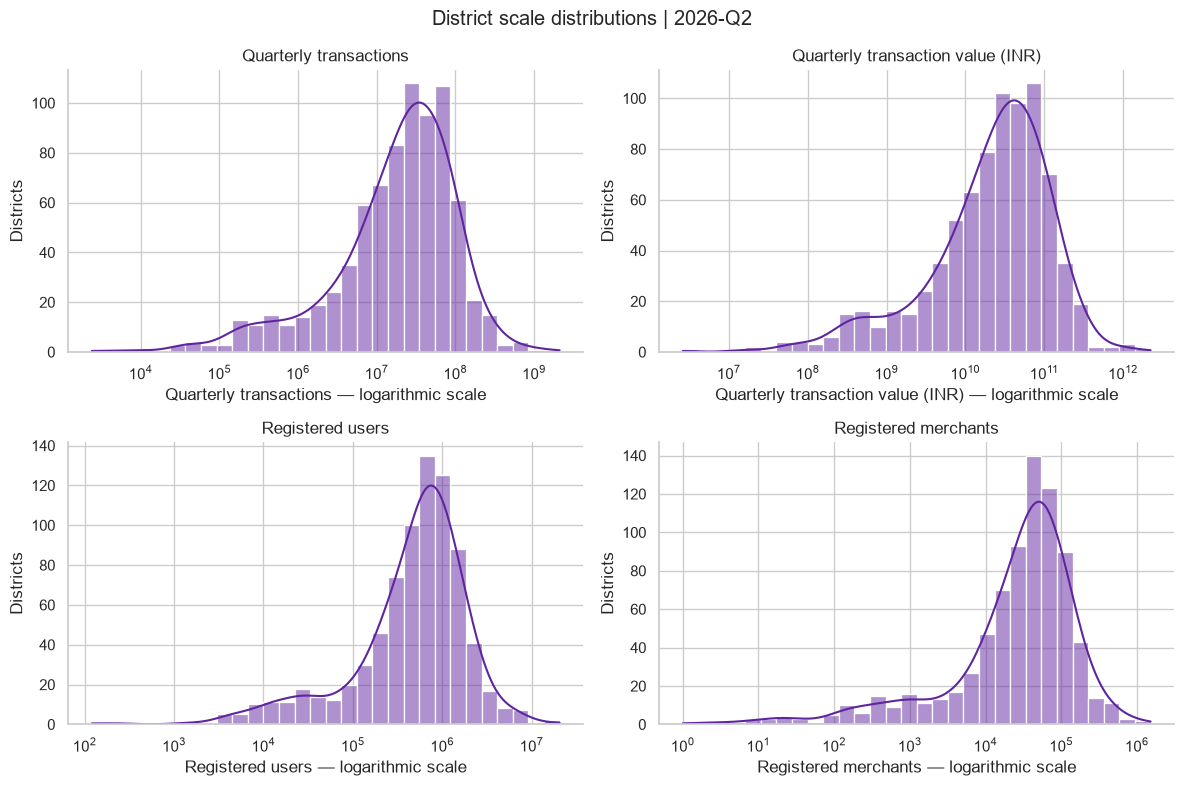

In [3]:
scale_metrics = {
    "transaction_count": "Quarterly transactions",
    "transaction_amount": "Quarterly transaction value (INR)",
    "registered_users": "Registered users",
    "registered_merchants": "Registered merchants",
}

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for axis, (column, label) in zip(
    axes.flat,
    scale_metrics.items(),
    strict=True,
):
    sns.histplot(
        data=latest_districts,
        x=column,
        bins=30,
        kde=True,
        color=purple,
        log_scale=True,
        ax=axis,
    )
    axis.set_title(label)
    axis.set_xlabel(f"{label} — logarithmic scale")
    axis.set_ylabel("Districts")

fig.suptitle(f"District scale distributions | {latest_period}")
fig.tight_layout()
plt.show()

### Insight

The logarithmic view reveals a broad range of district sizes without removing the largest markets. The median district records **24,446,442 transactions**, **611,315 registered users**, and **38,854 registered merchants**. The long upper tails show why absolute demand should be considered alongside growth and penetration rather than used as the only expansion signal.

### Merchant Penetration and Transaction Growth

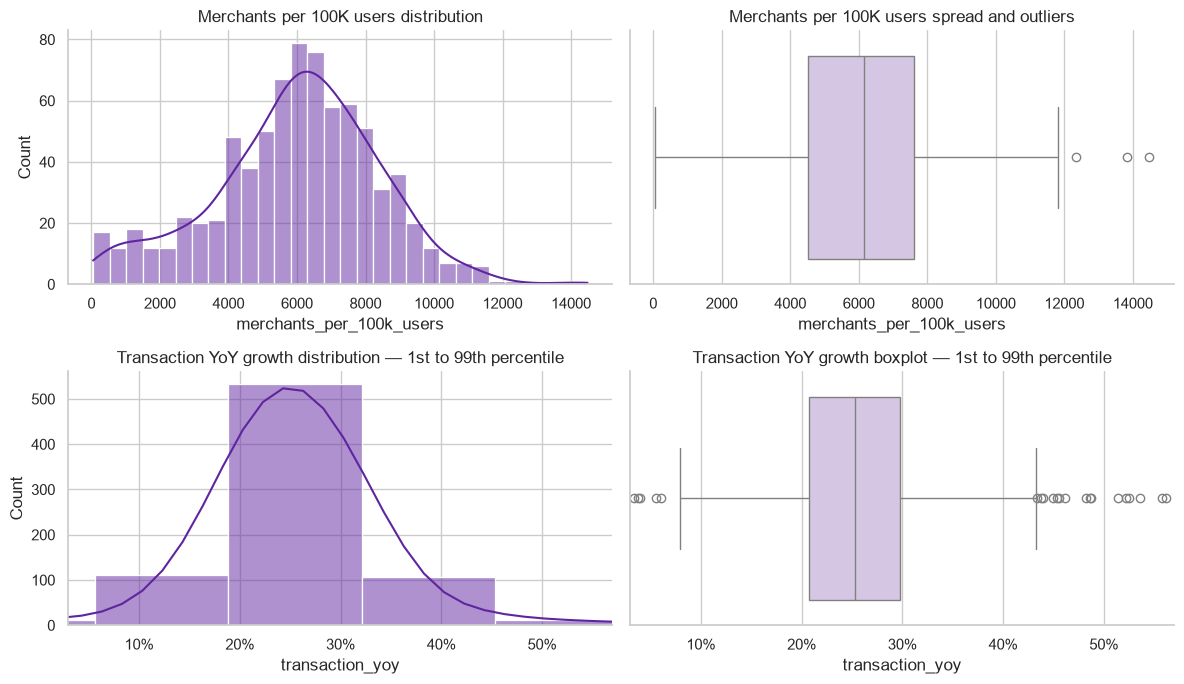

In [4]:
distribution_metrics = {
    "merchants_per_100k_users": "Merchants per 100K users",
    "transaction_yoy": "Transaction YoY growth",
}

fig, axes = plt.subplots(2, 2, figsize=(12, 7))

for row_number, (column, label) in enumerate(distribution_metrics.items()):
    sns.histplot(
        data=latest_districts,
        x=column,
        bins=30,
        kde=True,
        color=purple,
        ax=axes[row_number, 0],
    )
    sns.boxplot(
        data=latest_districts,
        x=column,
        color="#D5C2E8",
        ax=axes[row_number, 1],
    )
    axes[row_number, 0].set_title(f"{label} distribution")
    axes[row_number, 1].set_title(f"{label} spread and outliers")

    if column == "transaction_yoy":
        lower_limit = latest_districts[column].quantile(0.01)
        upper_limit = latest_districts[column].quantile(0.99)
        axes[row_number, 0].set_xlim(lower_limit, upper_limit)
        axes[row_number, 1].set_xlim(lower_limit, upper_limit)
        axes[row_number, 0].set_title(
            f"{label} distribution — 1st to 99th percentile"
        )
        axes[row_number, 1].set_title(
            f"{label} boxplot — 1st to 99th percentile"
        )

axes[1, 0].xaxis.set_major_formatter(PercentFormatter(1))
axes[1, 1].xaxis.set_major_formatter(PercentFormatter(1))
fig.tight_layout()
plt.show()

### Insight

The median district has **6,140 merchants per 100K registered users**, with an interquartile range of **4,531–7,609**. Median transaction YoY growth is **25.3%**. The 1.5×IQR rule identifies **37 growth outliers**, including a maximum of **389.9%**. The chart zooms to the 1st–99th percentile for readability, while the data and outliers remain unchanged.

## 4. National Trend

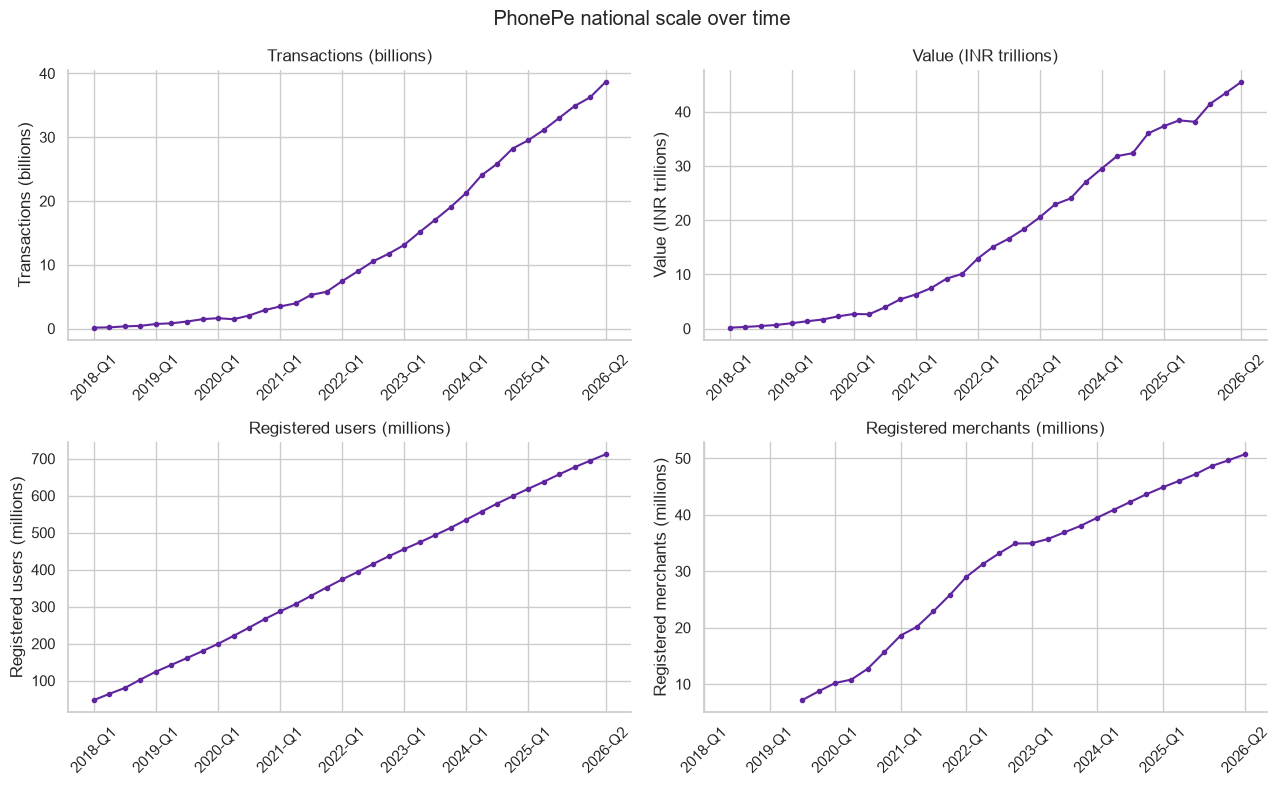

In [5]:
national_data["user_qoq"] = national_data["registered_users"].pct_change()
national_data["merchant_qoq"] = national_data[
    "registered_merchants"
].pct_change(fill_method=None)

trend_metrics = {
    "transaction_count": (1_000_000_000, "Transactions (billions)"),
    "transaction_amount": (1_000_000_000_000, "Value (INR trillions)"),
    "registered_users": (1_000_000, "Registered users (millions)"),
    "registered_merchants": (
        1_000_000,
        "Registered merchants (millions)",
    ),
}

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
tick_positions = list(range(0, len(national_data), 4))
final_position = len(national_data) - 1

if final_position - tick_positions[-1] <= 2:
    tick_positions[-1] = final_position
else:
    tick_positions.append(final_position)

for axis, (column, (divisor, label)) in zip(
    axes.flat,
    trend_metrics.items(),
    strict=True,
):
    axis.plot(
        national_data["period_label"],
        national_data[column] / divisor,
        color=purple,
        marker=".",
    )
    axis.set_title(label)
    axis.set_ylabel(label)
    axis.set_xticks(
        tick_positions,
        national_data["period_label"].iloc[tick_positions],
        rotation=45,
    )

fig.suptitle("PhonePe national scale over time")
fig.tight_layout()
plt.show()

### National Growth Measures

In [6]:
first_period = national_data.iloc[0]
latest_national = national_data.iloc[-1]
first_merchant_period = national_data.dropna(
    subset=["registered_merchants"]
).iloc[0]

national_growth = pd.DataFrame(
    {
        "metric": [
            "Latest transaction QoQ growth",
            "Latest transaction-value QoQ growth",
            "Latest registered-user QoQ growth",
            "Latest registered-merchant QoQ growth",
            "Transaction growth since 2018 Q1",
            "Registered-user growth since 2018 Q1",
            (
                "Registered-merchant growth since "
                f"{first_merchant_period['period_label']}"
            ),
        ],
        "growth": [
            latest_national["transaction_qoq"],
            latest_national["tpv_qoq"],
            latest_national["user_qoq"],
            latest_national["merchant_qoq"],
            (
                latest_national["transaction_count"]
                / first_period["transaction_count"]
                - 1
            ),
            (
                latest_national["registered_users"]
                / first_period["registered_users"]
                - 1
            ),
            (
                latest_national["registered_merchants"]
                / first_merchant_period["registered_merchants"]
                - 1
            ),
        ],
    }
)
national_growth["growth_percentage"] = (
    national_growth["growth"].mul(100).round(1).astype(str) + "%"
)
display(national_growth[["metric", "growth_percentage"]])

,metric,growth_percentage
0,Latest transaction QoQ growth,6.7%
1,Latest transaction-value QoQ growth,4.7%
2,Latest registered-user QoQ growth,2.5%
3,Latest registered-merchant QoQ growth,2.1%
4,Transaction growth since 2018 Q1,27521.6%
5,Registered-user growth since 2018 Q1,1398.7%
6,Registered-merchant growth since 2019-Q3,606.7%


### Insight

National transactions reached **38.66 billion** in 2026 Q2, up **6.7% QoQ**. Transaction value reached **INR 45.50 trillion**, up **4.7% QoQ**. The long-run expansion confirms a large and growing ecosystem, but national growth cannot identify local merchant-registration gaps by itself.

## 5. State-Level Analysis

In [7]:
state_ranking_metrics = {
    "transaction_count": "Top states by transactions",
    "transaction_amount": "Top states by transaction value",
    "registered_users": "Top states by registered users",
    "registered_merchants": "Top states by registered merchants",
}

for column, title in state_ranking_metrics.items():
    ranking = latest_states.nlargest(5, column)[["state", column]].copy()
    ranking["state"] = ranking["state"].str.title()
    print(title)
    display(ranking.reset_index(drop=True))

state_transaction_ranking = latest_states.sort_values(
    "transaction_count",
    ascending=False,
).copy()
state_transaction_ranking["transaction_share"] = (
    state_transaction_ranking["transaction_count"]
    / state_transaction_ranking["transaction_count"].sum()
)

concentration_summary = pd.DataFrame(
    {
        "group": ["Top five states", "Top ten states"],
        "transaction_share": [
            state_transaction_ranking.head(5)["transaction_share"].sum(),
            state_transaction_ranking.head(10)["transaction_share"].sum(),
        ],
    }
)
concentration_summary["transaction_share"] = (
    concentration_summary["transaction_share"]
    .mul(100)
    .round(1)
    .astype(str)
    + "%"
)
display(concentration_summary)

Top states by transactions


,state,transaction_count
0,Maharashtra,5064451991
1,Karnataka,4491711923
2,Telangana,3878232440
3,Uttar Pradesh,3665306240
4,Andhra Pradesh,3245956863


Top states by transaction value


,state,transaction_amount
0,Maharashtra,5.465177e+12
1,Karnataka,5.292341e+12
2,Telangana,5.128046e+12
3,Andhra Pradesh,4.623697e+12
4,Uttar Pradesh,3.938705e+12


Top states by registered users


,state,registered_users
0,Uttar Pradesh,90563992
1,Maharashtra,84075442
2,Karnataka,52534800
3,Bihar,44813491
4,Rajasthan,43692290


Top states by registered merchants


,state,registered_merchants
0,Uttar Pradesh,7866204.0
1,Maharashtra,6113793.0
2,West Bengal,3631496.0
3,Rajasthan,3314270.0
4,Karnataka,3305459.0


,group,transaction_share
0,Top five states,52.6%
1,Top ten states,79.6%


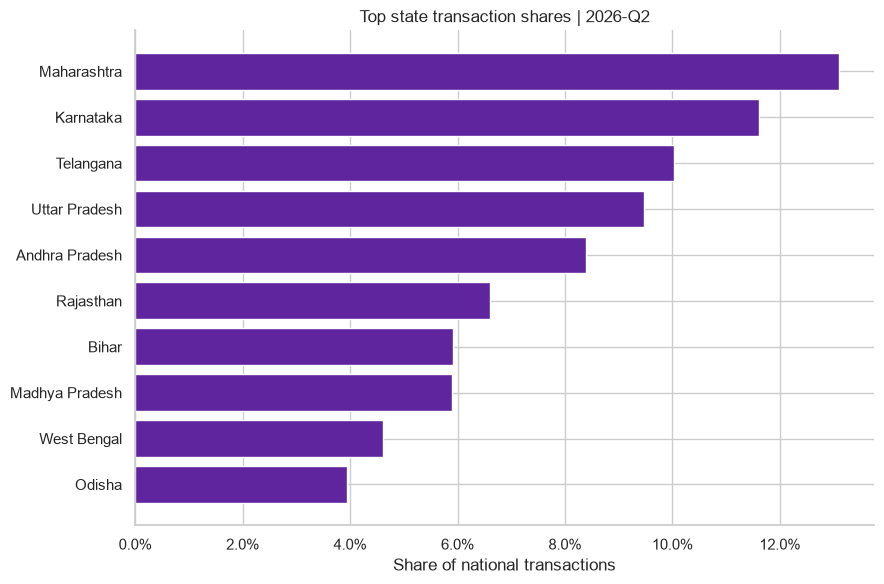

In [8]:
top_states_chart = state_transaction_ranking.head(10).sort_values(
    "transaction_share"
)

fig, axis = plt.subplots(figsize=(9, 6))
axis.barh(
    top_states_chart["state"].str.title(),
    top_states_chart["transaction_share"],
    color=purple,
)
axis.xaxis.set_major_formatter(PercentFormatter(1))
axis.set_title(f"Top state transaction shares | {latest_period}")
axis.set_xlabel("Share of national transactions")
axis.set_ylabel("")
fig.tight_layout()
plt.show()

### Insight

**Maharashtra** leads current transaction volume. The top five states contribute **52.6%** of national transactions, and the top ten contribute **79.6%**. This concentration matters for market scale, but large states may already have dense merchant registration. Expansion screening therefore needs district-level growth and penetration measures in addition to state size.

## 6. District-Level Demand

### Sizeable-District Filter

For growth and penetration comparisons, a district must have at least **100,000 registered users**, **1,000 registered merchants**, **1 million quarterly transactions**, and valid transaction YoY, user QoQ, and merchant QoQ history. The filter reduces unstable rankings caused by very small denominators while retaining all districts in the earlier distribution analysis.

In [9]:
sizeable_districts = latest_districts.loc[
    latest_districts["registered_users"].ge(100_000)
    & latest_districts["registered_merchants"].ge(1_000)
    & latest_districts["transaction_count"].ge(1_000_000)
    & latest_districts[
        ["transaction_yoy", "user_qoq", "merchant_qoq"]
    ].notna().all(axis=1)
].copy()

filter_summary = pd.DataFrame(
    {
        "districts_before_filter": [len(latest_districts)],
        "districts_after_filter": [len(sizeable_districts)],
        "retained_percentage": [
            len(sizeable_districts) / len(latest_districts)
        ],
    }
)
filter_summary["retained_percentage"] = (
    filter_summary["retained_percentage"]
    .mul(100)
    .round(1)
    .astype(str)
    + "%"
)
display(filter_summary)

,districts_before_filter,districts_after_filter,retained_percentage
0,783,680,86.8%


### Insight

The filter retains **680 of 783 districts (86.8%)**. These districts form a more comparable research universe; excluded districts remain valid observations but do not have enough scale or history for stable growth-and-penetration comparisons.

### Largest Districts

In [10]:
largest_by_transactions = latest_districts.nlargest(
    10,
    "transaction_count",
)[
    [
        "state",
        "district",
        "transaction_count",
        "registered_users",
        "transaction_yoy",
        "merchants_per_100k_users",
    ]
]

largest_by_users = latest_districts.nlargest(
    10,
    "registered_users",
)[
    [
        "state",
        "district",
        "registered_users",
        "transaction_count",
        "transaction_yoy",
        "merchants_per_100k_users",
    ]
]

print("Largest districts by quarterly transactions")
display(largest_by_transactions.reset_index(drop=True))
print("Largest districts by registered users")
display(largest_by_users.reset_index(drop=True))

Largest districts by quarterly transactions


,state,district,transaction_count,registered_users,transaction_yoy,merchants_per_100k_users
0,karnataka,bengaluru urban,2.113433e+09,20543058,0.173172,7387.624569
1,maharashtra,pune,1.190116e+09,14753740,0.230502,8552.441618
2,telangana,rangareddy,8.453297e+08,7229570,0.254740,6253.719101
3,telangana,medchal malkajgiri,7.590408e+08,6313836,0.240344,7211.115398
4,rajasthan,jaipur,6.372599e+08,7999367,0.159128,10172.004860
5,telangana,hyderabad,5.720922e+08,5840094,0.213475,7422.175054
6,uttar pradesh,gautambuddha nagar,4.314158e+08,5609621,0.217466,7606.627970
7,haryana,gurugram,4.052013e+08,5282943,0.195865,6768.840777
8,maharashtra,thane,3.464772e+08,8346491,0.249760,8882.175755
9,madhya pradesh,indore,3.398951e+08,4118995,0.219451,8691.707565


Largest districts by registered users


,state,district,registered_users,transaction_count,transaction_yoy,merchants_per_100k_users
0,karnataka,bengaluru urban,20543058,2.113433e+09,0.173172,7387.624569
1,maharashtra,pune,14753740,1.190116e+09,0.230502,8552.441618
2,maharashtra,thane,8346491,3.464772e+08,0.249760,8882.175755
3,rajasthan,jaipur,7999367,6.372599e+08,0.159128,10172.004860
4,maharashtra,mumbai suburban,7625449,2.819981e+08,0.229858,9831.814494
5,telangana,rangareddy,7229570,8.453297e+08,0.254740,6253.719101
6,gujarat,ahmedabad,6724772,2.607001e+08,0.270977,7660.155616
7,telangana,medchal malkajgiri,6313836,7.590408e+08,0.240344,7211.115398
8,tamil nadu,chennai,6215686,1.796799e+08,0.157302,6714.624902
9,west bengal,north twenty four parganas,6080783,2.709292e+08,0.229787,8656.237198


### Insight

**Bengaluru Urban** is the largest district by transactions, while **Bengaluru Urban** has the largest registered-user base. Large districts offer reach, but their current merchant density must be checked before treating scale as an acquisition gap.

### Growth, Penetration, and Repeated Signals

In [11]:
fastest_growing = sizeable_districts.nlargest(
    10,
    "transaction_yoy",
)[
    [
        "state",
        "district",
        "transaction_yoy",
        "transaction_count",
        "registered_users",
        "merchants_per_100k_users",
    ]
]

lowest_penetration = sizeable_districts.nsmallest(
    10,
    "merchants_per_100k_users",
)[
    [
        "state",
        "district",
        "merchants_per_100k_users",
        "users_per_merchant",
        "transaction_count",
        "transaction_yoy",
    ]
]

print("Fastest-growing sizeable districts")
display(fastest_growing.reset_index(drop=True))
print("Lowest merchant-penetration sizeable districts")
display(lowest_penetration.reset_index(drop=True))

signal_tables = {
    "High transactions": largest_by_transactions,
    "Large user base": largest_by_users,
    "Fast growth": fastest_growing,
    "Low penetration": lowest_penetration,
}

repeated_signals = pd.concat(
    [
        table[["state", "district"]].assign(signal=signal_name)
        for signal_name, table in signal_tables.items()
    ],
    ignore_index=True,
)
repeated_signals = (
    repeated_signals.groupby(["state", "district"])
    .agg(
        signal_count=("signal", "size"),
        signals=("signal", ", ".join),
    )
    .query("signal_count >= 2")
    .sort_values(
        ["signal_count", "state", "district"],
        ascending=[False, True, True],
    )
    .reset_index()
)
display(repeated_signals)

Fastest-growing sizeable districts


,state,district,transaction_yoy,transaction_count,registered_users,merchants_per_100k_users
0,assam,darrang,0.524498,21610773.0,412727,8629.917597
1,mizoram,aizawl,0.482547,2457520.0,164163,9994.334899
2,assam,morigaon,0.455173,18226572.0,432252,7595.106558
3,bihar,jehanabad,0.434015,20442084.0,416235,4292.767307
4,punjab,kapurthala,0.433081,10609846.0,364471,6039.163610
5,gujarat,jamnagar,0.431148,21411527.0,728437,4454.468952
6,assam,udalguri,0.431144,8475087.0,285968,6700.400045
7,meghalaya,east khasi hills,0.422817,6655012.0,253230,2656.083402
8,assam,kamrup,0.418580,28257339.0,710607,7520.894109
9,assam,hojai,0.411021,19368667.0,442831,6139.588240


Lowest merchant-penetration sizeable districts


,state,district,merchants_per_100k_users,users_per_merchant,transaction_count,transaction_yoy
0,ladakh,leh ladakh,915.430826,109.238183,6775664.0,0.190227
1,chhattisgarh,bijapur,1166.049585,85.759646,4987418.0,0.120457
2,chhattisgarh,dantewada,1900.172005,52.626815,5794933.0,0.149878
3,himachal pradesh,shimla,2199.185112,45.471388,7992452.0,0.131379
4,jharkhand,gumla,2234.479220,44.753157,8157749.0,0.205061
5,gujarat,narmada,2240.029032,44.642279,4126831.0,0.206592
6,jharkhand,jamtara,2352.653227,42.505202,7915444.0,0.189194
7,jharkhand,simdega,2456.514467,40.708085,3902634.0,0.239025
8,gujarat,morbi,2464.408081,40.577695,17114095.0,0.097571
9,goa,south goa,2485.683791,40.230379,22941591.0,0.154569


,state,district,signal_count,signals
0,karnataka,bengaluru urban,2,"High transactions, Large user base"
1,maharashtra,pune,2,"High transactions, Large user base"
2,maharashtra,thane,2,"High transactions, Large user base"
3,rajasthan,jaipur,2,"High transactions, Large user base"
4,telangana,medchal malkajgiri,2,"High transactions, Large user base"
5,telangana,rangareddy,2,"High transactions, Large user base"


### Insight

**Darrang** has the fastest YoY transaction growth among sizeable districts, while **Leh Ladakh** has the lowest relative merchant registration. Districts appearing in multiple tables deserve attention because they combine signals; a single extreme rank is less persuasive than repeated evidence across demand, scale, growth, and penetration.

## 7. Merchant Penetration Analysis

In [12]:
penetration_summary = sizeable_districts[
    ["merchants_per_100k_users", "users_per_merchant"]
].quantile([0.25, 0.50, 0.75])
penetration_summary.index = ["25th percentile", "Median", "75th percentile"]

display(penetration_summary.round(2))

penetration_columns = [
    "state",
    "district",
    "merchants_per_100k_users",
    "users_per_merchant",
    "registered_users",
    "transaction_yoy",
]

print("Lowest merchant penetration")
display(
    sizeable_districts.nsmallest(
        10,
        "merchants_per_100k_users",
    )[penetration_columns].reset_index(drop=True)
)

print("Highest merchant penetration")
display(
    sizeable_districts.nlargest(
        10,
        "merchants_per_100k_users",
    )[penetration_columns].reset_index(drop=True)
)

,merchants_per_100k_users,users_per_merchant
25th percentile,5278.22,12.90
Median,6441.49,15.52
75th percentile,7751.07,18.95


Lowest merchant penetration


,state,district,merchants_per_100k_users,users_per_merchant,registered_users,transaction_yoy
0,ladakh,leh ladakh,915.430826,109.238183,177949,0.190227
1,chhattisgarh,bijapur,1166.049585,85.759646,106685,0.120457
2,chhattisgarh,dantewada,1900.172005,52.626815,123252,0.149878
3,himachal pradesh,shimla,2199.185112,45.471388,434661,0.131379
4,jharkhand,gumla,2234.479220,44.753157,272860,0.205061
5,gujarat,narmada,2240.029032,44.642279,170846,0.206592
6,jharkhand,jamtara,2352.653227,42.505202,335026,0.189194
7,jharkhand,simdega,2456.514467,40.708085,143496,0.239025
8,gujarat,morbi,2464.408081,40.577695,731697,0.097571
9,goa,south goa,2485.683791,40.230379,625864,0.154569


Highest merchant penetration


,state,district,merchants_per_100k_users,users_per_merchant,registered_users,transaction_yoy
0,madhya pradesh,burhanpur,14479.338554,6.906393,343006,0.246424
1,uttar pradesh,bhadohi,13837.699514,7.226635,522081,0.294393
2,madhya pradesh,bhopal,12350.471867,8.096857,2930803,0.211092
3,west bengal,murshidabad,11814.128139,8.464442,3131835,0.258517
4,uttar pradesh,sambhal,11509.469662,8.688498,819195,0.295387
5,uttar pradesh,shamli,11295.391785,8.853168,602945,0.248468
6,delhi,south east,11272.471249,8.871169,2525338,0.193899
7,haryana,kaithal,11231.031405,8.903902,492920,0.252377
8,rajasthan,kota,11183.113198,8.942054,1566004,0.213193
9,uttar pradesh,shravasti,11126.541309,8.987519,267873,0.346711


### Insight

Among sizeable districts, median merchant penetration is **6,441 merchants per 100K users**; the middle half ranges from **5,278 to 7,751**. Lower penetration can indicate a relative registration gap, but it is not enough on its own. A useful candidate should also have a meaningful user base and payment demand.

## 8. User Growth vs Merchant Growth

In [13]:
sizeable_districts["growth_gap"] = (
    sizeable_districts["user_qoq"]
    - sizeable_districts["merchant_qoq"]
)

user_growth_leads = sizeable_districts["growth_gap"].gt(0)
growth_gap_summary = pd.DataFrame(
    {
        "measure": [
            "Districts where user growth exceeds merchant growth",
            "Districts where merchant growth meets or exceeds user growth",
        ],
        "district_count": [
            int(user_growth_leads.sum()),
            int((~user_growth_leads).sum()),
        ],
        "district_share": [
            user_growth_leads.mean(),
            (~user_growth_leads).mean(),
        ],
    }
)
growth_gap_summary["district_share"] = (
    growth_gap_summary["district_share"]
    .mul(100)
    .round(1)
    .astype(str)
    + "%"
)
display(growth_gap_summary)

gap_columns = [
    "state",
    "district",
    "user_qoq",
    "merchant_qoq",
    "growth_gap",
    "registered_users",
]

print("Largest positive user-minus-merchant growth gaps")
display(
    sizeable_districts.nlargest(10, "growth_gap")[
        gap_columns
    ].reset_index(drop=True)
)

print("Districts where merchant growth most exceeds user growth")
display(
    sizeable_districts.nsmallest(10, "growth_gap")[
        gap_columns
    ].reset_index(drop=True)
)

,measure,district_count,district_share
0,Districts where user growth exceeds merchant g...,338,49.7%
1,Districts where merchant growth meets or excee...,342,50.3%


Largest positive user-minus-merchant growth gaps


,state,district,user_qoq,merchant_qoq,growth_gap,registered_users
0,jammu & kashmir,ganderbal,0.178974,0.024228,0.154746,128599
1,jammu & kashmir,anantnag,0.101392,0.023671,0.077721,396835
2,tamil nadu,kancheepuram,0.050545,0.011062,0.039483,1058912
3,chhattisgarh,bijapur,0.040880,0.003226,0.037654,106685
4,ladakh,leh ladakh,0.047116,0.011801,0.035315,177949
5,punjab,moga,0.044561,0.009405,0.035156,319177
6,punjab,barnala,0.049927,0.015075,0.034851,208611
7,punjab,mansa,0.045187,0.012016,0.033171,255495
8,punjab,tarn taran,0.044757,0.013353,0.031404,360111
9,punjab,sri muktsar sahib,0.040298,0.009485,0.030813,323828


Districts where merchant growth most exceeds user growth


,state,district,user_qoq,merchant_qoq,growth_gap,registered_users
0,meghalaya,west garo hills,0.037072,0.438956,-0.401884,198200
1,assam,south salmara mankachar,-0.027417,0.318315,-0.345733,164915
2,assam,dhubri,-0.027032,0.216491,-0.243523,704855
3,uttarakhand,rudraprayag,-0.150967,0.038921,-0.189888,100742
4,assam,goalpara,0.003614,0.179508,-0.175895,482678
5,uttarakhand,chamoli,-0.053056,0.073739,-0.126795,145515
6,himachal pradesh,kullu,-0.035806,0.061278,-0.097084,266297
7,tripura,gomati,0.042103,0.134522,-0.092419,129970
8,uttarakhand,uttarkashi,-0.058206,0.016662,-0.074868,117001
9,maharashtra,sindhudurg,-0.028084,0.040148,-0.068232,296619


### Insight

User growth exceeds merchant-registration growth in **49.7% of sizeable districts**. A positive gap may justify deeper merchant-coverage investigation because the registered-user base is expanding faster than merchant registrations. It is a screening signal, not proof of a merchant shortage, because registrations do not measure active users or active merchants.

## 9. Bivariate Analysis

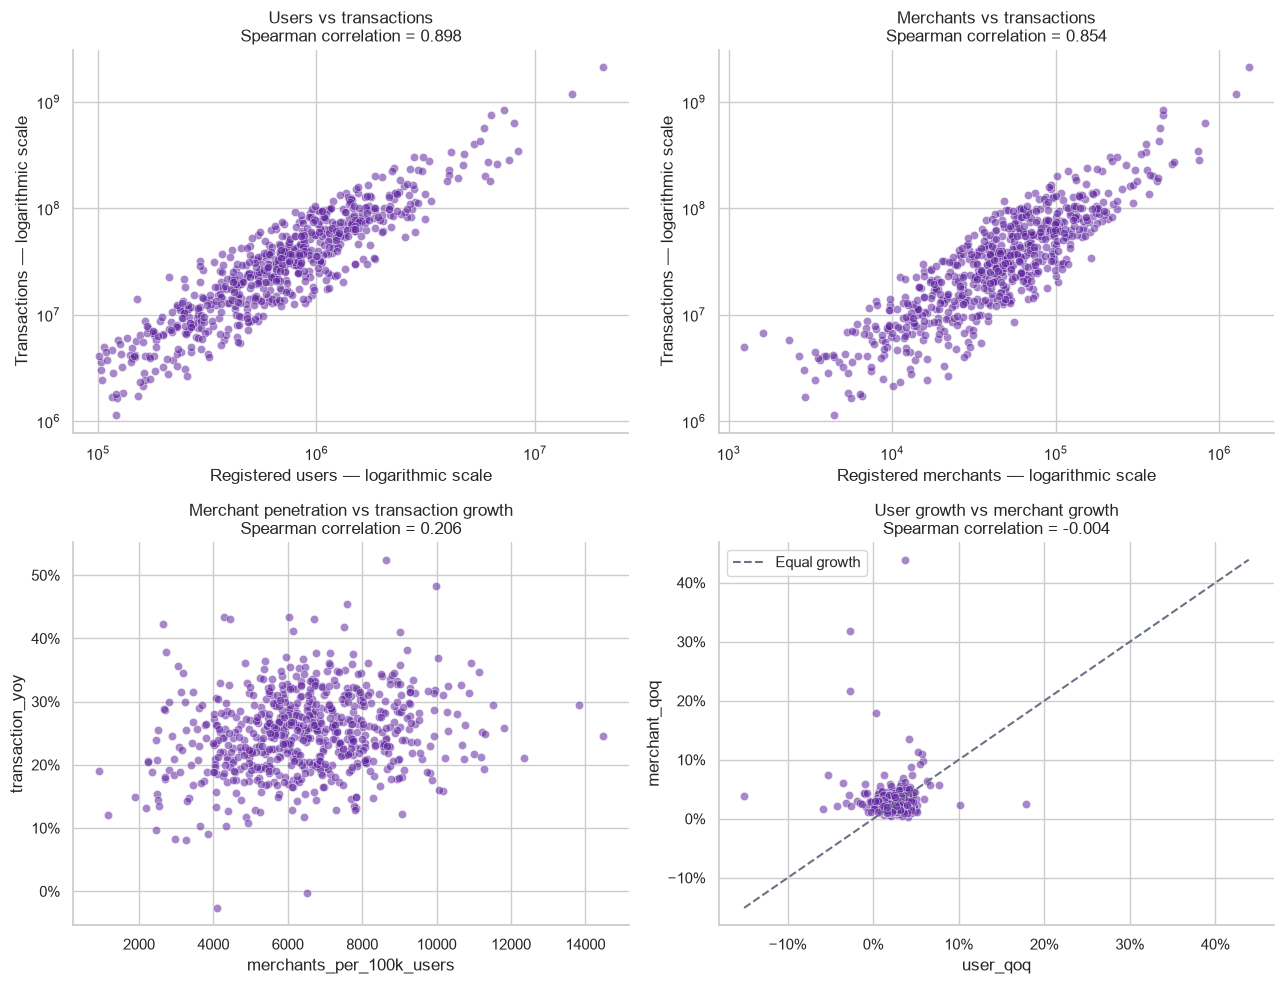

,relationship,spearman_correlation
0,Users vs transactions,0.898
1,Merchants vs transactions,0.854
2,Merchant penetration vs transaction growth,0.206
3,User growth vs merchant growth,-0.004


In [14]:
bivariate_pairs = [
    (
        "registered_users",
        "transaction_count",
        "Users vs transactions",
    ),
    (
        "registered_merchants",
        "transaction_count",
        "Merchants vs transactions",
    ),
    (
        "merchants_per_100k_users",
        "transaction_yoy",
        "Merchant penetration vs transaction growth",
    ),
    (
        "user_qoq",
        "merchant_qoq",
        "User growth vs merchant growth",
    ),
]

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
correlation_rows = []

for axis, (x_column, y_column, title) in zip(
    axes.flat,
    bivariate_pairs,
    strict=True,
):
    sns.scatterplot(
        data=sizeable_districts,
        x=x_column,
        y=y_column,
        color=purple,
        alpha=0.55,
        s=35,
        ax=axis,
    )

    correlation = sizeable_districts[[x_column, y_column]].corr(
        method="spearman"
    ).iloc[0, 1]
    correlation_rows.append(
        {
            "relationship": title,
            "spearman_correlation": correlation,
        }
    )
    axis.set_title(f"{title}\nSpearman correlation = {correlation:.3f}")

axes[0, 0].set_xscale("log")
axes[0, 0].set_yscale("log")
axes[0, 1].set_xscale("log")
axes[0, 1].set_yscale("log")
axes[0, 0].set_xlabel("Registered users — logarithmic scale")
axes[0, 0].set_ylabel("Transactions — logarithmic scale")
axes[0, 1].set_xlabel("Registered merchants — logarithmic scale")
axes[0, 1].set_ylabel("Transactions — logarithmic scale")
axes[1, 0].yaxis.set_major_formatter(PercentFormatter(1))
axes[1, 1].xaxis.set_major_formatter(PercentFormatter(1))
axes[1, 1].yaxis.set_major_formatter(PercentFormatter(1))

growth_minimum = min(
    sizeable_districts["user_qoq"].min(),
    sizeable_districts["merchant_qoq"].min(),
)
growth_maximum = max(
    sizeable_districts["user_qoq"].max(),
    sizeable_districts["merchant_qoq"].max(),
)
axes[1, 1].plot(
    [growth_minimum, growth_maximum],
    [growth_minimum, growth_maximum],
    color=gray,
    linestyle="--",
    label="Equal growth",
)
axes[1, 1].legend()

fig.tight_layout()
plt.show()
display(pd.DataFrame(correlation_rows).round(3))

### Insight

Registered users have a Spearman correlation of **0.898** with transactions, and registered merchants have a correlation of **0.854**. These strong scale relationships explain why large markets dominate raw activity. Merchant penetration and transaction growth have a much weaker correlation of **0.206**, so low penetration does not automatically imply stronger growth.

## 10. Multivariate Opportunity View

### Quadrant Definition

In [15]:
penetration_median = sizeable_districts[
    "merchants_per_100k_users"
].median()
growth_median = sizeable_districts["transaction_yoy"].median()

sizeable_districts["opportunity_quadrant"] = ""
high_growth = sizeable_districts["transaction_yoy"].ge(growth_median)
low_penetration = sizeable_districts[
    "merchants_per_100k_users"
].lt(penetration_median)

sizeable_districts.loc[
    high_growth & low_penetration,
    "opportunity_quadrant",
] = "High growth / Low penetration"
sizeable_districts.loc[
    high_growth & ~low_penetration,
    "opportunity_quadrant",
] = "High growth / High penetration"
sizeable_districts.loc[
    ~high_growth & low_penetration,
    "opportunity_quadrant",
] = "Low growth / Low penetration"
sizeable_districts.loc[
    ~high_growth & ~low_penetration,
    "opportunity_quadrant",
] = "Low growth / High penetration"



quadrant_counts = (
    sizeable_districts["opportunity_quadrant"]
    .value_counts()
    .rename("district_count")
    .rename_axis("quadrant")
    .reset_index()
)
display(quadrant_counts)

,quadrant,district_count
0,Low growth / Low penetration,194
1,High growth / High penetration,194
2,High growth / Low penetration,146
3,Low growth / High penetration,146


### Quadrant Chart

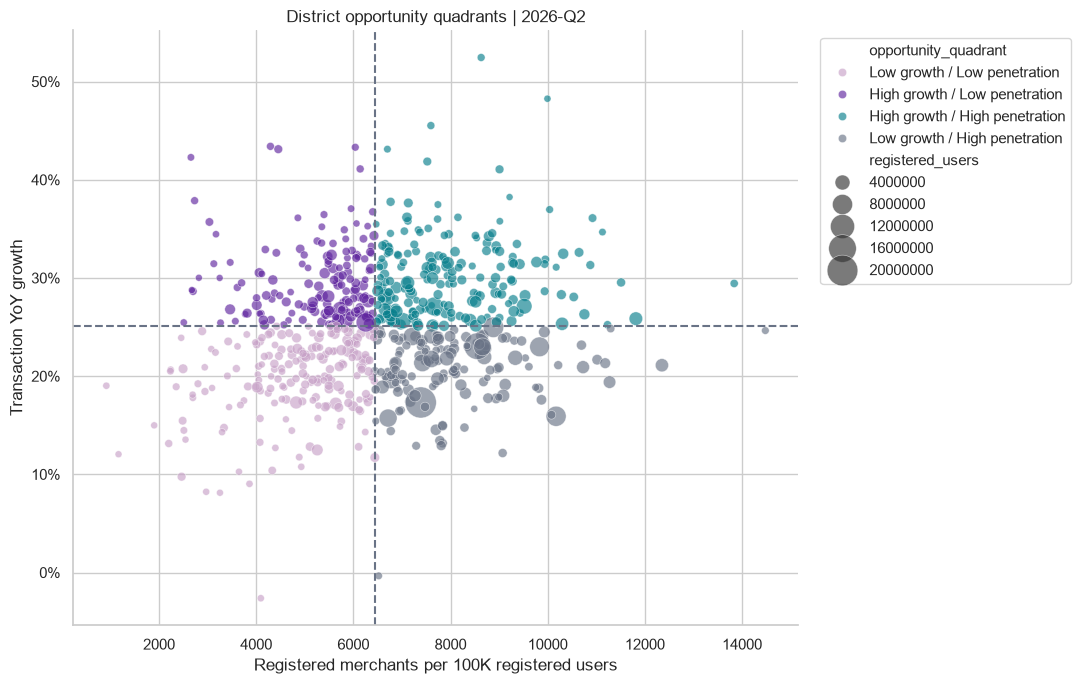

In [16]:
quadrant_palette = {
    "High growth / Low penetration": purple,
    "High growth / High penetration": teal,
    "Low growth / Low penetration": "#C8A2C8",
    "Low growth / High penetration": gray,
}

fig, axis = plt.subplots(figsize=(11, 7))
sns.scatterplot(
    data=sizeable_districts,
    x="merchants_per_100k_users",
    y="transaction_yoy",
    size="registered_users",
    hue="opportunity_quadrant",
    palette=quadrant_palette,
    sizes=(25, 500),
    alpha=0.65,
    ax=axis,
)
axis.axvline(penetration_median, color=gray, linestyle="--")
axis.axhline(growth_median, color=gray, linestyle="--")
axis.yaxis.set_major_formatter(PercentFormatter(1))
axis.set_title(f"District opportunity quadrants | {latest_period}")
axis.set_xlabel("Registered merchants per 100K registered users")
axis.set_ylabel("Transaction YoY growth")
axis.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
fig.tight_layout()
plt.show()

### Candidate Summary

In [17]:
exploratory_candidates = sizeable_districts.loc[
    sizeable_districts["opportunity_quadrant"].eq(
        "High growth / Low penetration"
    )
].copy()

candidate_summary = pd.DataFrame(
    {
        "candidate_count": [len(exploratory_candidates)],
        "candidate_share": [
            len(exploratory_candidates) / len(sizeable_districts)
        ],
        "penetration_reference": [penetration_median],
        "growth_reference": [growth_median],
    }
)
candidate_summary["candidate_share"] = (
    candidate_summary["candidate_share"]
    .mul(100)
    .round(1)
    .astype(str)
    + "%"
)
candidate_summary["penetration_reference"] = (
    candidate_summary["penetration_reference"].round(0).astype(int)
)
candidate_summary["growth_reference"] = (
    candidate_summary["growth_reference"]
    .mul(100)
    .round(1)
    .astype(str)
    + "%"
)
display(candidate_summary)

candidate_states = (
    exploratory_candidates["state"]
    .value_counts()
    .rename("candidate_count")
    .head(10)
    .rename_axis("state")
    .reset_index()
)
display(candidate_states)

,candidate_count,candidate_share,penetration_reference,growth_reference
0,146,21.5%,6441,25.1%


,state,candidate_count
0,maharashtra,19
1,andhra pradesh,17
2,gujarat,14
3,telangana,14
4,assam,13
5,bihar,10
6,karnataka,9
7,punjab,8
8,madhya pradesh,7
9,jharkhand,5


### Insight

**146 sizeable districts (21.5%)** fall in the high-growth, low-penetration quadrant. **Maharashtra** contains the largest number of these exploratory candidates, with **19 districts**. These markets combine relative growth and penetration signals, but the quadrant is an exploratory screen rather than the final Opportunity Score.

## 11. Correlation Analysis

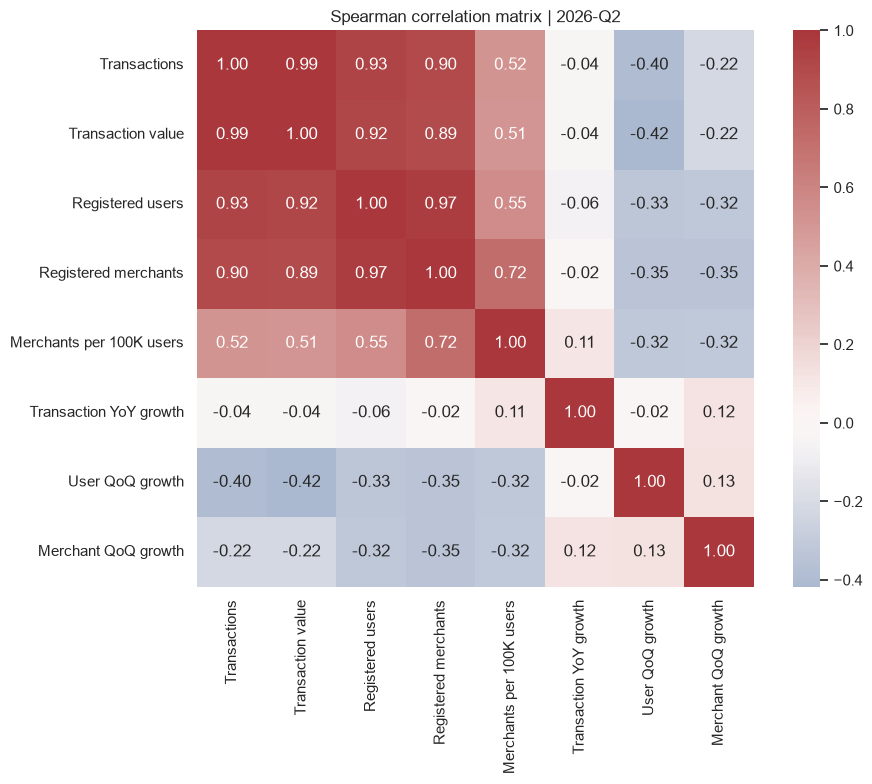

In [18]:
correlation_labels = {
    "transaction_count": "Transactions",
    "transaction_amount": "Transaction value",
    "registered_users": "Registered users",
    "registered_merchants": "Registered merchants",
    "merchants_per_100k_users": "Merchants per 100K users",
    "transaction_yoy": "Transaction YoY growth",
    "user_qoq": "User QoQ growth",
    "merchant_qoq": "Merchant QoQ growth",
}

correlation_matrix = latest_districts[
    list(correlation_labels)
].corr(method="spearman")
correlation_matrix = correlation_matrix.rename(
    index=correlation_labels,
    columns=correlation_labels,
)

fig, axis = plt.subplots(figsize=(10, 8))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="vlag",
    center=0,
    square=True,
    ax=axis,
)
axis.set_title(f"Spearman correlation matrix | {latest_period}")
fig.tight_layout()
plt.show()

### Insight

Transaction count and transaction value have the strongest relationship at **0.994**. Users, merchants, and transactions are also strongly related because they all reflect market scale, creating potential redundancy if all are heavily weighted in one score. Growth and merchant penetration show weaker relationships, so they add different information. **Correlation does not imply causation.**

## 12. Transaction Category Analysis

In [19]:
latest_category_data = category_data.loc[
    category_data["period_id"].eq(latest_period_id)
].copy()

category_summary = (
    latest_category_data.groupby("category", as_index=False)[
        "transaction_count"
    ]
    .sum()
    .sort_values("transaction_count", ascending=False)
)
category_summary["category_share"] = (
    category_summary["transaction_count"]
    / category_summary["transaction_count"].sum()
)
category_display = category_summary.copy()
category_display["transaction_count"] = (
    category_display["transaction_count"].round(0).astype(int)
)
category_display["category_share"] = (
    category_display["category_share"]
    .mul(100)
    .round(1)
    .astype(str)
    + "%"
)
display(category_display)

,category,transaction_count,category_share
1,Retail,24691181013,63.9%
0,P2P,11889781621,30.8%
2,Utility,2083323057,5.4%


### Recent Category Trend

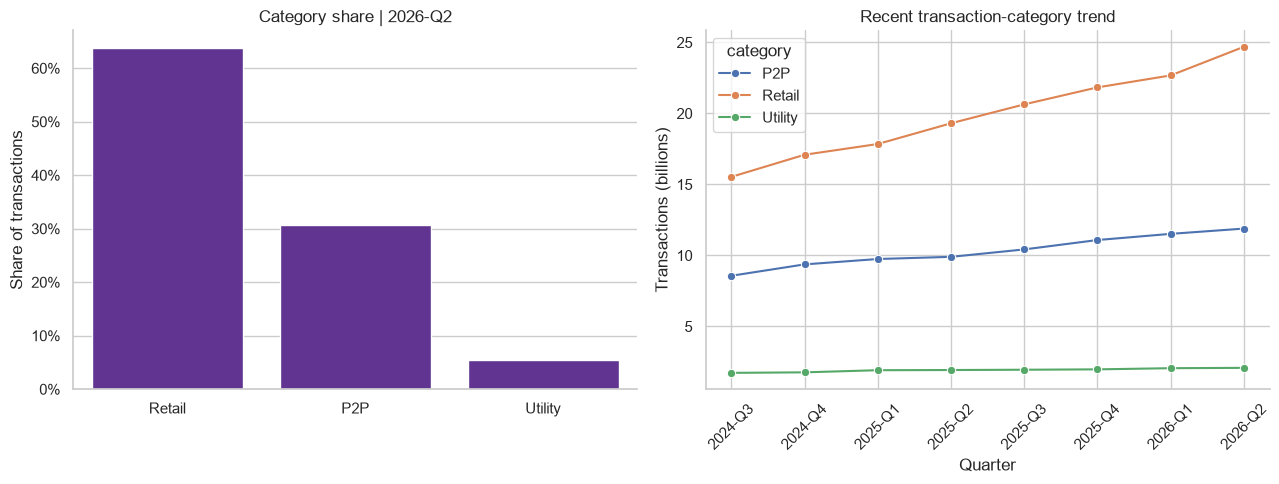

In [20]:
recent_period_ids = national_data.tail(8)["period_id"]
recent_category_data = category_data.loc[
    category_data["period_id"].isin(recent_period_ids)
].copy()
recent_category_trend = (
    recent_category_data.groupby(
        ["period_id", "category"],
        as_index=False,
    )["transaction_count"]
    .sum()
    .merge(
        national_data[["period_id", "period_label"]],
        on="period_id",
        how="left",
    )
)
recent_category_trend["transactions_billions"] = (
    recent_category_trend["transaction_count"] / 1_000_000_000
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.barplot(
    data=category_summary,
    x="category",
    y="category_share",
    color=purple,
    ax=axes[0],
)
axes[0].yaxis.set_major_formatter(PercentFormatter(1))
axes[0].set_title(f"Category share | {latest_period}")
axes[0].set_ylabel("Share of transactions")
axes[0].set_xlabel("")

sns.lineplot(
    data=recent_category_trend,
    x="period_label",
    y="transactions_billions",
    hue="category",
    marker="o",
    ax=axes[1],
)
axes[1].set_title("Recent transaction-category trend")
axes[1].set_xlabel("Quarter")
axes[1].set_ylabel("Transactions (billions)")
axes[1].tick_params(axis="x", rotation=45)

fig.tight_layout()
plt.show()

### Insight

**Retail** is the largest reported category, representing **63.9%** of 2026 Q2 transaction count. Category mix affects the commercial interpretation of aggregate demand. District transaction totals contain ecosystem activity and must not automatically be interpreted as merchant-only payment transactions.

## 13. Final EDA Insights

1. National transactions reached **38.66 billion** in 2026 Q2, with **6.7% QoQ growth**. The ecosystem has meaningful current momentum, suggesting that district screening should focus on where demand growth is paired with lower relative merchant registration.

2. Transaction value reached **INR 45.50 trillion**, growing **4.7% QoQ**. Value and count need to be read together because the difference may reflect payment mix as well as payment frequency.

3. **Maharashtra** leads state transaction volume, while the top five states contribute **52.6%**. This concentration helps size operational reach, but it does not prove that these states have a merchant-acceptance gap.

4. **Bengaluru Urban** leads district transactions with **2,113,433,404**, while **Bengaluru Urban** has the largest registered-user base. Large markets warrant attention, subject to local merchant-density evidence.

5. Median sizeable-district merchant penetration is **6,441 merchants per 100K users**. Districts below this benchmark need adequate demand and growth before being treated as expansion candidates.

6. **Darrang** has the strongest YoY transaction growth among sizeable districts at **52.4%**. Its transaction base should be checked because a single growth rate can overstate the importance of a smaller market.

7. **Leh Ladakh** has the lowest merchant penetration among sizeable districts. This is a relative registration signal and does not prove that active merchants are scarce.

8. User growth exceeds merchant growth in **49.7% of sizeable districts**. These districts may warrant merchant-coverage investigation, subject to active-user and active-merchant validation.

9. The high-growth, low-penetration quadrant contains **146 districts (21.5%)**. **Maharashtra** contributes the most, with **19 candidates**, making it a useful region for deeper scoring rather than an automatic expansion decision.

10. Transactions and transaction value have a Spearman correlation of **0.994**, while **Retail** represents **63.9%** of current transactions. Scale measures may be redundant, and category mix confirms that district totals cannot be treated as merchant-only payments.